# Label Augmentation Pipeline Demo

This notebook demonstrates the **label augmentation** pipeline used during GliZNet training, using the `ZSHOT-HARDSET-v2` dataset.

## Pipeline overview (applied sequentially)

1. **ScenarioAwareSampler** — targets real-world inference patterns:
   - **needle** (20%): exactly 1 positive among many negatives (standard single-label ZSC)
   - **few_pos** (15%): pick n_neg (min 4), then n_pos in [0, n_neg]. Negatives dominate. Naturally includes all-negative and needle-like cases.
   - **few_neg** (10%): pick n_pos (min 4), then n_neg in [0, n_pos]. Positives dominate. Naturally includes all-positive cases.
   - **balanced** (10%): ~50/50 positive/negative
   - **passthrough** (45%): keep original distribution
2. **LabelLimit** — caps total labels, shuffles order, replaces underscores (with ratio-preserving stratified sampling)

In [1]:
import sys
sys.path.insert(0, "..")

import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from gliznet.augmentation import (
    load_augmentation_pipeline,
    load_label_augmentation_pipeline,
    ScenarioAwareSampler,
    LabelLimit,
    LabelSimplification,
    LabelAugmentationPipeline,
    AUGMENTATION_REGISTRY,
)
from gliznet.augmentation.label import LabelTokenMask
from gliznet.data import load_dataset, _add_cross_sample_negatives

random.seed(42)
np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Load V2 Dataset Samples

Load a few samples from `alexneakameni/ZSHOT-HARDSET-v2` to see original label distributions.

In [2]:
ds = load_dataset("alexneakameni/ZSHOT-HARDSET-v2", split="test")
print(f"Dataset size: {len(ds)} samples")
print(f"Columns: {ds.column_names}")
print()

# Show 5 samples
for i in range(5):
    sample = ds[i]
    pos = sum(sample["lint"])
    neg = len(sample["lint"]) - pos
    print(f"Sample {i}: text='{sample['text'][:80]}...'")
    print(f"  Labels ({len(sample['ltext'])} total): {pos} positive, {neg} negative")
    print(f"  ltext: {sample['ltext'][:8]}{'...' if len(sample['ltext']) > 8 else ''}")
    print(f"  lint:  {sample['lint'][:8]}{'...' if len(sample['lint']) > 8 else ''}")
    print()

Map:   0%|          | 0/9045 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9045 [00:00<?, ? examples/s]

Dataset size: 9045 samples
Columns: ['text', 'ltext', 'lint']

Sample 0: text='A highly significant acquisition, this item possesses an aura of authenticated a...'
  Labels (8 total): 4 positive, 4 negative
  ltext: ['implied_rarity_assertion', 'archival_metadata_reference', 'cataloging_of_disposal', 'contextual_periodization', 'expert_authentication_claim', 'assessment_of_material_integrity', 'aesthetic_valuation_criteria', 'documentation_of_provenance']
  lint:  [1, 0, 0, 0, 1, 0, 1, 1]

Sample 1: text='One critical factor driving the creation of this new structure was the poor cond...'
  Labels (8 total): 4 positive, 4 negative
  ltext: ['transitional_replacement_narrative', 'naming_conventions_explanation', 'structural_necessity_argument', 'pedagogical_definition_provision', 'historical_chronology_reporting', 'locational_specification_detail', 'instructional_exemplification', 'safety_concern_justification']
  lint:  [1, 0, 1, 1, 0, 0, 0, 1]

Sample 2: text='The historical record sh

## 2. ScenarioAwareSampler — Before vs After

The sampler explicitly targets inference patterns the model will encounter at test time.
Each sample is randomly assigned to one scenario (or passthrough).

In [3]:
# Demo each scenario explicitly on the same sample
sample = ds[0]
ltext, lint = sample["ltext"], sample["lint"]
pos_orig = sum(lint)
neg_orig = len(lint) - pos_orig

print(f"Original sample: {pos_orig} pos, {neg_orig} neg (total {len(lint)})")
print(f"  text: '{sample['text'][:80]}...'\n")

# Call each scenario method directly
sampler = ScenarioAwareSampler()
positives, negatives = sampler._split(ltext, lint)

scenarios = {
    "NEEDLE":      lambda: sampler._needle(list(positives), list(negatives)),
    "FEW_POS":     lambda: sampler._few_pos(list(positives), list(negatives)),
    "FEW_NEG":     lambda: sampler._few_neg(list(positives), list(negatives)),
    "BALANCED":    lambda: sampler._balanced(list(positives), list(negatives)),
    "PASSTHROUGH": lambda: list(positives) + list(negatives),
}

print("=" * 65)
for name, fn in scenarios.items():
    result = fn()
    if result is None:
        print(f"  {name:<15} → not feasible (not enough labels)")
        continue
    out_t, out_i = sampler._merge(result)
    n_pos = sum(out_i)
    n_neg = len(out_i) - n_pos
    print(f"  {name:<15} → {n_pos} pos, {n_neg} neg (total {len(out_i)})")
    print(f"    {out_t[:5]}{'...' if len(out_t) > 5 else ''}\n")

Original sample: 4 pos, 4 neg (total 8)
  text: 'A highly significant acquisition, this item possesses an aura of authenticated a...'

  NEEDLE          → 1 pos, 4 neg (total 5)
    ['archival_metadata_reference', 'cataloging_of_disposal', 'contextual_periodization', 'expert_authentication_claim', 'assessment_of_material_integrity']

  FEW_POS         → 1 pos, 4 neg (total 5)
    ['cataloging_of_disposal', 'assessment_of_material_integrity', 'archival_metadata_reference', 'contextual_periodization', 'expert_authentication_claim']

  FEW_NEG         → 4 pos, 3 neg (total 7)
    ['assessment_of_material_integrity', 'aesthetic_valuation_criteria', 'contextual_periodization', 'documentation_of_provenance', 'expert_authentication_claim']...

  BALANCED        → 3 pos, 3 neg (total 6)
    ['implied_rarity_assertion', 'cataloging_of_disposal', 'contextual_periodization', 'expert_authentication_claim', 'archival_metadata_reference']...

  PASSTHROUGH     → 4 pos, 4 neg (total 8)
    ['contextu

### 2.1 Hard Negative Priority

When `hard_negative_prob > 0`, the sampler biases negative selection toward labels sharing tokens with the positives. Uses the **Gumbel-top-k trick** for exact weighted sampling without replacement.

Example: for a text about `market_analysis`, `economic_policy` (shares "market"/"economic" tokens) is a harder negative than `sports_coverage` and gets preferentially selected.

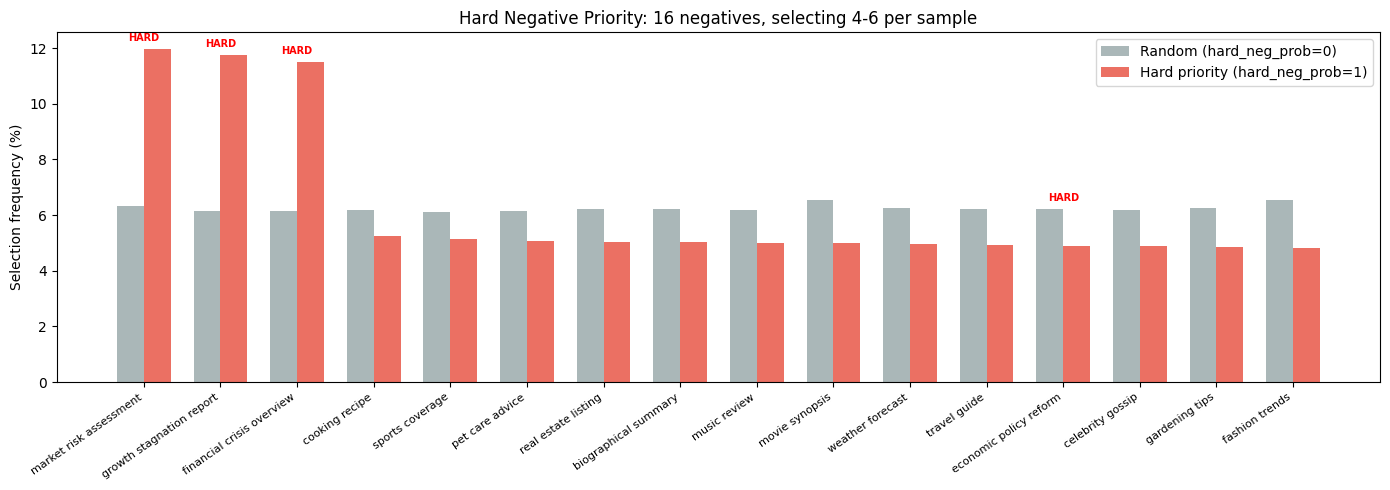

Positives: market_bullish_sentiment, financial_growth_analysis
Hard negatives (share tokens): 24.9% (random) → 40.1% (hard priority)
Uplift: 1.6x more likely to select confusable negatives


In [6]:
# Compare negative selection: random vs hard-negative-biased
# Need many negatives so needle (selects 4-6) reveals selection bias
labels_demo = [
    "market_bullish_sentiment", "financial_growth_analysis",  # 2 positives
    # Hard negatives (share tokens with positives)
    "economic_policy_reform", "market_risk_assessment",
    "financial_crisis_overview", "growth_stagnation_report",
    # Easy negatives (no token overlap)
    "biographical_summary", "sports_coverage", "weather_forecast",
    "cooking_recipe", "music_review", "travel_guide",
    "gardening_tips", "pet_care_advice", "fashion_trends",
    "movie_synopsis", "celebrity_gossip", "real_estate_listing",
]
ints_demo = [1, 1] + [0] * 16

N_trials = 3000
sampler_random = ScenarioAwareSampler(needle_prob=1.0, hard_negative_prob=0.0,
                                       needle_min_neg=4, needle_max_neg=6)
sampler_hard = ScenarioAwareSampler(needle_prob=1.0, hard_negative_prob=1.0,
                                     needle_min_neg=4, needle_max_neg=6)

neg_counts_random = Counter()
neg_counts_hard = Counter()

for _ in range(N_trials):
    texts_r, ints_r = sampler_random(labels_demo[:], ints_demo[:])
    for t, i in zip(texts_r, ints_r):
        if i == 0:
            neg_counts_random[t.replace("_", " ")] += 1

    texts_h, ints_h = sampler_hard(labels_demo[:], ints_demo[:])
    for t, i in zip(texts_h, ints_h):
        if i == 0:
            neg_counts_hard[t.replace("_", " ")] += 1

# Sort by hard-priority frequency descending
all_negs = sorted(
    set(neg_counts_random.keys()) | set(neg_counts_hard.keys()),
    key=lambda n: neg_counts_hard.get(n, 0), reverse=True,
)
pcts_random = [100 * neg_counts_random.get(n, 0) / max(sum(neg_counts_random.values()), 1) for n in all_negs]
pcts_hard = [100 * neg_counts_hard.get(n, 0) / max(sum(neg_counts_hard.values()), 1) for n in all_negs]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(all_negs))
w = 0.35
ax.bar(x - w/2, pcts_random, w, label="Random (hard_neg_prob=0)", color="#95a5a6", alpha=0.8)
ax.bar(x + w/2, pcts_hard, w, label="Hard priority (hard_neg_prob=1)", color="#e74c3c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_negs, fontsize=8, rotation=35, ha="right")
ax.set_ylabel("Selection frequency (%)")
ax.set_title("Hard Negative Priority: 16 negatives, selecting 4-6 per sample")
ax.legend()

# Annotate hard negatives
hard_tokens = {"market", "financial", "growth", "economic"}
for i, neg in enumerate(all_negs):
    is_hard = bool(set(neg.lower().split()) & hard_tokens)
    if is_hard:
        ax.annotate("HARD", (i, max(pcts_random[i], pcts_hard[i]) + 0.3),
                    ha="center", fontsize=7, color="red", fontweight="bold")

plt.tight_layout()
plt.show()

hard_pct = sum(pcts_hard[i] for i, n in enumerate(all_negs) if set(n.lower().split()) & hard_tokens)
rand_pct = sum(pcts_random[i] for i, n in enumerate(all_negs) if set(n.lower().split()) & hard_tokens)
print(f"Positives: market_bullish_sentiment, financial_growth_analysis")
print(f"Hard negatives (share tokens): {rand_pct:.1f}% (random) → {hard_pct:.1f}% (hard priority)")
print(f"Uplift: {hard_pct/max(rand_pct, 0.1):.1f}x more likely to select confusable negatives")

## 3. LabelLimit (ratio-preserving)

After scenario sampling, `LabelLimit` applies:
- Caps total labels to `max_labels` (default 20)
- **Stratified sampling** (`preserve_ratio=True`): truncation keeps the pos/neg ratio set by the upstream sampler
- Shuffles label order (randomizes position each epoch)
- Replaces underscores with spaces 90% of the time

In [7]:
# Compare preserve_ratio=True vs False on a needle scenario (1 pos + 10 neg)
print("LabelLimit: preserve_ratio=True vs False\n" + "=" * 60)
print("Input: 1 positive + 10 negatives, truncated to max_labels=6\n")

limit_preserve = LabelLimit(max_labels=6, min_labels=3, preserve_ratio=True)
limit_naive = LabelLimit(max_labels=6, min_labels=3, preserve_ratio=False)

N_trials = 3000
kept_preserve, kept_naive = 0, 0

for _ in range(N_trials):
    inp_t = ["pos_0"] + [f"neg_{i}" for i in range(10)]
    inp_i = [1] + [0] * 10
    _, out_i = limit_preserve(inp_t[:], inp_i[:])
    kept_preserve += sum(out_i)
    _, out_i2 = limit_naive(inp_t[:], inp_i[:])
    kept_naive += sum(out_i2)

print(f"  preserve_ratio=True:  positive kept {kept_preserve/N_trials:.2f}/1.00 avg")
print(f"  preserve_ratio=False: positive kept {kept_naive/N_trials:.2f}/1.00 avg")
print(f"\n  → Without preserve_ratio, {100*(1-kept_naive/N_trials):.0f}% of needle samples lose their positive!")

# Also show underscore replacement
print("\n\nUnderscore replacement demo:")
demo_labels = ["machine_learning", "natural_language_processing", "deep_learning"]
demo_ints = [1, 0, 0]
limit_demo = LabelLimit(max_labels=20, remove_underscores=0.9)
out_t, out_i = limit_demo(demo_labels[:], demo_ints[:])
print(f"  Input:  {demo_labels}")
print(f"  Output: {out_t}")

LabelLimit: preserve_ratio=True vs False
Input: 1 positive + 10 negatives, truncated to max_labels=6

  preserve_ratio=True:  positive kept 1.00/1.00 avg
  preserve_ratio=False: positive kept 0.45/1.00 avg

  → Without preserve_ratio, 55% of needle samples lose their positive!


Underscore replacement demo:
  Input:  ['machine_learning', 'natural_language_processing', 'deep_learning']
  Output: ['natural language processing', 'machine learning']


## 3.5 LabelSimplification — Compositional Transfer

Extracts individual tokens (≥4 chars) from multi-token positive labels and adds them as additional positives. This teaches the model that `"historical"` is also correct when `"historical_contextualization"` is positive — compositional transfer without reducing label diversity.

LabelSimplification Demo (prob=1.0, max_added=3, min_token_len=4)

  Input positives: ['historical_contextualization', 'political_analysis']
  Added:           [('historical', 1), ('contextualization', 1), ('political', 1)]

  Input positives: ['sentiment positive', 'market bullish outlook']
  Added:           [('sentiment', 1), ('positive', 1), ('market', 1)]

  Input positives: ['AI', 'deep_learning_model']
  Added:           [('deep', 1), ('learning', 1), ('model', 1)]


--- Statistics on real dataset samples ---
Samples: 1000
Mean added labels:   3.00
Samples with adds:   1000 (100.0%)
Max added:           3


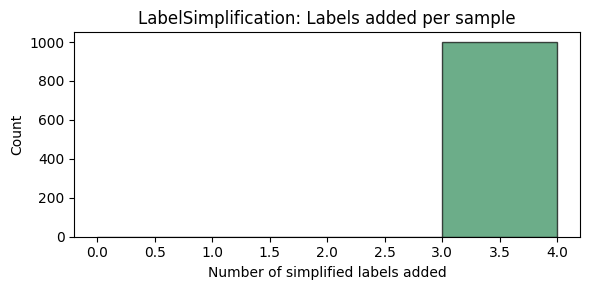

In [8]:
simp = LabelSimplification(prob=1.0, max_added=3, min_token_len=4)

# Demo on several multi-token labels
demo_cases = [
    (["historical_contextualization", "political_analysis", "economic_overview"],
     [1, 1, 0]),
    (["sentiment positive", "market bullish outlook", "sports news"],
     [1, 1, 0]),
    (["AI", "NLP", "deep_learning_model"],
     [1, 0, 1]),
]

print("LabelSimplification Demo (prob=1.0, max_added=3, min_token_len=4)\n" + "=" * 70)
for labels, ints in demo_cases:
    out_t, out_i = simp(labels[:], ints[:])
    added = [(t, i) for t, i in zip(out_t[len(labels):], out_i[len(labels):])]
    print(f"\n  Input positives: {[l for l, i in zip(labels, ints) if i == 1]}")
    print(f"  Added:           {added if added else '(none — single-token or too short)'}")

# Distribution: how many labels get added on real data?
print("\n\n--- Statistics on real dataset samples ---")
N_simp = min(1000, len(ds))
added_counts = []
for i in range(N_simp):
    sample = ds[i]
    ltext, lint = sample["ltext"], sample["lint"]
    out_t, _ = simp(ltext[:], lint[:])
    added_counts.append(len(out_t) - len(ltext))

print(f"Samples: {N_simp}")
print(f"Mean added labels:   {np.mean(added_counts):.2f}")
print(f"Samples with adds:   {sum(1 for c in added_counts if c > 0)} ({100*sum(1 for c in added_counts if c > 0)/N_simp:.1f}%)")
print(f"Max added:           {max(added_counts)}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(added_counts, bins=range(0, max(added_counts) + 2), edgecolor="black", alpha=0.7, color="seagreen")
ax.set_xlabel("Number of simplified labels added")
ax.set_ylabel("Count")
ax.set_title("LabelSimplification: Labels added per sample")
plt.tight_layout()
plt.show()

## 3.6 LabelTokenMask — Partial Label Matching

Randomly replaces tokens within multi-token labels with `[MASK]`. Forces the model to attend to partial cues rather than memorizing exact label strings. Single-token labels are always preserved.

Key insight: at inference, users provide simple labels like `"positive"` while training data has verbose labels like `"sentiment_positive_strong"`. Token masking bridges this gap.

In [9]:
masker = LabelTokenMask(prob=1.0, token_mask_prob=0.3, mask_token="[MASK]")

# Demo on multi-token labels
demo_labels = [
    "financial_growth_reporting",
    "sentiment_positive",
    "historical contextualization analysis",
    "positive",          # single-token → always preserved
    "news",              # single-token → always preserved
]

print("LabelTokenMask Demo (prob=1.0, token_mask_prob=0.3)\n" + "=" * 60)
print(f"{'Original':<45} → {'Masked':<45}")
print("-" * 95)

random.seed(42)
for label in demo_labels:
    masked = masker._mask_label(label)
    marker = "  (single-token, preserved)" if label == masked and " " not in label and "_" not in label else ""
    print(f"  {label:<43} → {masked:<43}{marker}")

# Run 5 times on same input to show stochasticity
print(f"\n\nStochastic masking (5 runs on same labels):\n" + "-" * 70)
multi_tok = ["financial_growth_reporting", "sentiment_positive_strong"]
for run in range(5):
    masked_out, _ = masker(multi_tok[:], [1, 0])
    print(f"  Run {run+1}: {masked_out}")

# Stats on real data
print(f"\n\n--- Token masking stats on real dataset ---")
N_mask = min(500, len(ds))
tokens_masked = 0
tokens_total = 0
labels_changed = 0
labels_total = 0

for i in range(N_mask):
    sample = ds[i]
    ltext = sample["ltext"]
    out_t, _ = masker(ltext[:], sample["lint"][:])
    for orig, masked in zip(ltext, out_t):
        sep = "_" if "_" in orig else " "
        orig_toks = orig.split(sep)
        masked_toks = masked.split(sep)
        if len(orig_toks) > 1:
            tokens_total += len(orig_toks)
            tokens_masked += sum(1 for o, m in zip(orig_toks, masked_toks) if o != m)
            if orig != masked:
                labels_changed += 1
            labels_total += 1

print(f"Multi-token labels: {labels_total}")
print(f"Labels changed:     {labels_changed} ({100*labels_changed/max(labels_total,1):.1f}%)")
print(f"Tokens masked:      {tokens_masked}/{tokens_total} ({100*tokens_masked/max(tokens_total,1):.1f}%)")

LabelTokenMask Demo (prob=1.0, token_mask_prob=0.3)
Original                                      → Masked                                       
-----------------------------------------------------------------------------------------------
  financial_growth_reporting                  → financial_[MASK]_[MASK]                    
  sentiment_positive                          → [MASK]_positive                            
  historical contextualization analysis       → historical contextualization [MASK]        
  positive                                    → positive                                     (single-token, preserved)
  news                                        → news                                         (single-token, preserved)


Stochastic masking (5 runs on same labels):
----------------------------------------------------------------------
  Run 1: ['[MASK]_[MASK]_reporting', '[MASK]_[MASK]_strong']
  Run 2: ['[MASK]_growth_reporting', '[MASK]_positive_strong']
  R

## 3.7 CrossSampleNegatives — In-Batch Hard Negative Sharing

Operates at the **batch level** (not per-sample). For each sample, steals positive labels from other samples in the batch as hard negatives — but only when they share tokens with this sample's positives.

Example: Sample A has positive `"market_analysis"` → Sample B's positive `"market_speculation"` becomes a hard negative for A (they share `"market"`).

In [10]:
# Synthetic batch demonstrating cross-sample negatives
batch_texts = [
    ["market_analysis", "financial_overview", "sports_news"],          # pos, pos, neg
    ["market_speculation", "economic_forecast", "cooking_tips"],       # pos, neg, neg
    ["political_commentary", "economic_analysis", "fashion_trends"],   # pos, pos, neg
    ["sports_analytics", "game_review", "weather_report"],             # pos, neg, neg
]
batch_ints = [
    [1, 1, 0],
    [1, 0, 0],
    [1, 1, 0],
    [1, 0, 0],
]

print("CrossSampleNegatives Demo (prob=1.0, max_added=2)\n" + "=" * 75)
print("\nBefore:")
for i, (texts, ints) in enumerate(zip(batch_texts, batch_ints)):
    pos = [t for t, v in zip(texts, ints) if v == 1]
    neg = [t for t, v in zip(texts, ints) if v == 0]
    print(f"  Sample {i}: pos={pos}, neg={neg}")

# Apply cross-sample negatives
bt_copy = [t[:] for t in batch_texts]
bi_copy = [i[:] for i in batch_ints]
bt_out, bi_out = _add_cross_sample_negatives(bt_copy, bi_copy, prob=1.0, max_added=2)

print("\nAfter:")
for i in range(len(bt_out)):
    orig_len = len(batch_texts[i])
    added = bt_out[i][orig_len:]
    pos = [t for t, v in zip(bt_out[i], bi_out[i]) if v == 1]
    neg = [t for t, v in zip(bt_out[i], bi_out[i]) if v == 0]
    print(f"  Sample {i}: pos={pos}, neg={neg}")
    if added:
        print(f"           → added as negatives: {added}")

# Stats on real data batch
print(f"\n\n--- Cross-sample stats on real dataset (batch_size=16) ---")
N_batch = 50
added_per_sample = []
for b in range(N_batch):
    start = b * 16
    end = min(start + 16, len(ds))
    if start >= len(ds):
        break
    bt = [ds[i]["ltext"][:] for i in range(start, end)]
    bi = [ds[i]["lint"][:] for i in range(start, end)]
    orig_lens = [len(t) for t in bt]
    bt, bi = _add_cross_sample_negatives(bt, bi, prob=1.0, max_added=2)
    for orig, new in zip(orig_lens, bt):
        added_per_sample.append(len(new) - orig)

print(f"Batches: {N_batch}, Samples: {len(added_per_sample)}")
print(f"Mean negatives added:    {np.mean(added_per_sample):.2f}")
print(f"Samples with additions:  {sum(1 for c in added_per_sample if c > 0)} ({100*sum(1 for c in added_per_sample if c > 0)/len(added_per_sample):.1f}%)")
print(f"Max added per sample:    {max(added_per_sample)}")

CrossSampleNegatives Demo (prob=1.0, max_added=2)

Before:
  Sample 0: pos=['market_analysis', 'financial_overview'], neg=['sports_news']
  Sample 1: pos=['market_speculation'], neg=['economic_forecast', 'cooking_tips']
  Sample 2: pos=['political_commentary', 'economic_analysis'], neg=['fashion_trends']
  Sample 3: pos=['sports_analytics'], neg=['game_review', 'weather_report']

After:
  Sample 0: pos=['market_analysis', 'financial_overview'], neg=['sports_news', 'market_speculation', 'economic_analysis']
           → added as negatives: ['market_speculation', 'economic_analysis']
  Sample 1: pos=['market_speculation'], neg=['economic_forecast', 'cooking_tips', 'market_analysis']
           → added as negatives: ['market_analysis']
  Sample 2: pos=['political_commentary', 'economic_analysis'], neg=['fashion_trends', 'market_analysis']
           → added as negatives: ['market_analysis']
  Sample 3: pos=['sports_analytics'], neg=['game_review', 'weather_report']


--- Cross-sample stat

## 4. Scenario Distribution

Run the sampler on many samples and classify which scenario was triggered to verify the distribution matches configured probabilities.

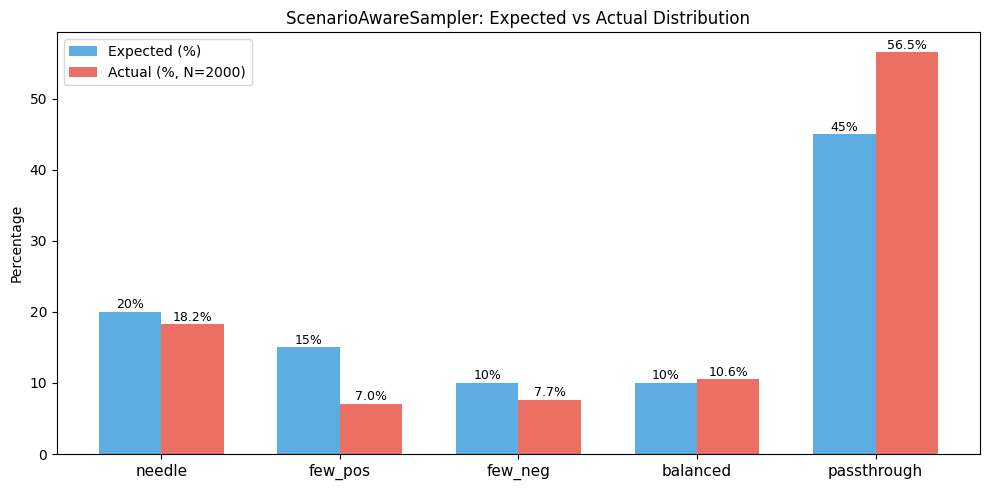


Scenario counts (N=2000):
  needle            365  (18.2%)
  few_pos           141  (7.0%)
  few_neg           153  (7.7%)
  balanced          211  (10.6%)
  passthrough      1130  (56.5%)


In [5]:
N = min(2000, len(ds))
scenarios = Counter()

# Replicate the scenario selection logic to track which was actually chosen
for i in range(N):
    sample = ds[i % len(ds)]
    ltext, lint = sample["ltext"], sample["lint"]
    positives, negatives = sampler._split(ltext, lint)

    r = random.random()
    cum = 0.0
    scenario_list = [
        (sampler.needle_prob, "needle", lambda: sampler._needle(list(positives), list(negatives))),
        (sampler.few_pos_prob, "few_pos", lambda: sampler._few_pos(list(positives), list(negatives))),
        (sampler.few_neg_prob, "few_neg", lambda: sampler._few_neg(list(positives), list(negatives))),
        (sampler.balanced_prob, "balanced", lambda: sampler._balanced(list(positives), list(negatives))),
    ]
    chosen = "passthrough"
    for prob, name, fn in scenario_list:
        cum += prob
        if r < cum:
            result = fn()
            chosen = name if result is not None else "passthrough"
            break
    scenarios[chosen] += 1

# Plot
labels_s = ["needle", "few_pos", "few_neg", "balanced", "passthrough"]
expected = [20, 15, 10, 10, 45]
actual = [100 * scenarios.get(s, 0) / N for s in labels_s]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels_s))
w = 0.35
ax.bar(x - w/2, expected, w, label="Expected (%)", color="#3498db", alpha=0.8)
ax.bar(x + w/2, actual, w, label=f"Actual (%, N={N})", color="#e74c3c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_s, fontsize=11)
ax.set_ylabel("Percentage")
ax.set_title("ScenarioAwareSampler: Expected vs Actual Distribution")
ax.legend()

for i, (e, a) in enumerate(zip(expected, actual)):
    ax.text(i - w/2, e + 0.5, f"{e}%", ha="center", fontsize=9)
    ax.text(i + w/2, a + 0.5, f"{a:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nScenario counts (N={N}):")
for s in labels_s:
    print(f"  {s:<15} {scenarios.get(s, 0):>5}  ({100*scenarios.get(s,0)/N:.1f}%)")

Per-scenario pos/neg statistics (N=2000 samples)
Scenario           n   pos_bef  neg_bef  ratio_bef   pos_aft  neg_aft  ratio_aft   tot_aft
---------------------------------------------------------------------------------------------------------
  needle        1736      3.93     6.65      0.592      1.00     5.76      0.174      6.76
  few_pos       1736      3.93     6.65      0.592      2.59     5.80      0.447      8.39
  few_neg       1635      4.09     6.24      0.656      4.07     2.71      1.502      6.78
  balanced      1992      3.89     6.18      0.630      3.26     3.26      1.000      6.52
  passthrough   2000      3.88     6.17      0.629      3.88     6.17      0.629     10.05


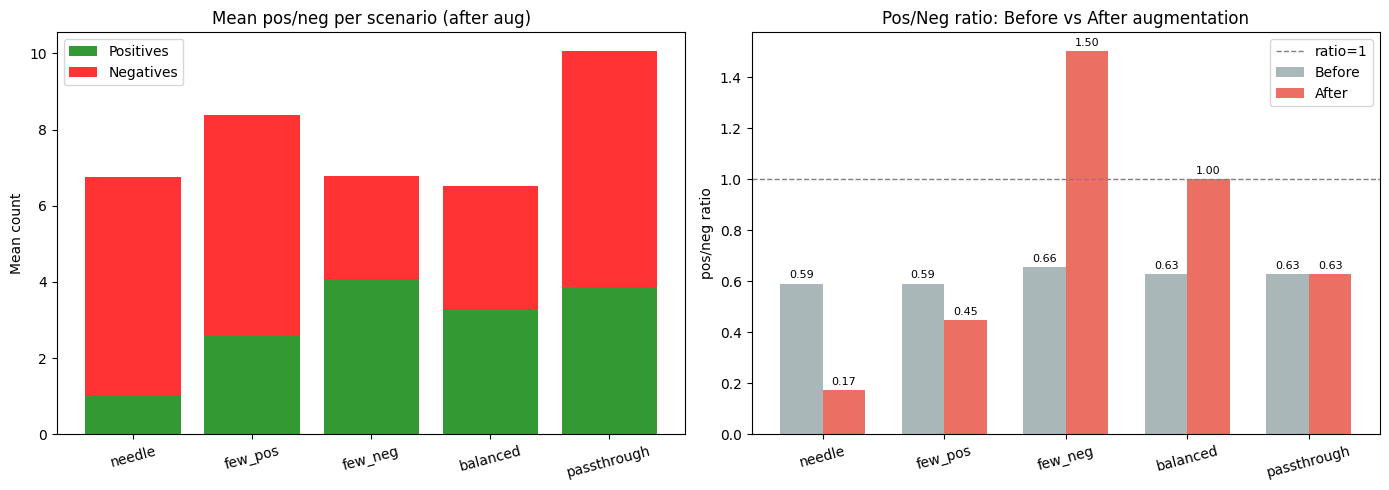

In [6]:
# Per-scenario pos/neg ratio analysis
N_ratio = min(2000, len(ds))
scenario_names = ["needle", "few_pos", "few_neg", "balanced", "passthrough"]
stats = {s: {"pos_bef": [], "neg_bef": [], "pos_aft": [], "neg_aft": [], "total_aft": []} for s in scenario_names}

scenario_fns = {
    "needle":      lambda s, p, n: s._needle(list(p), list(n)),
    "few_pos":     lambda s, p, n: s._few_pos(list(p), list(n)),
    "few_neg":     lambda s, p, n: s._few_neg(list(p), list(n)),
    "balanced":    lambda s, p, n: s._balanced(list(p), list(n)),
    "passthrough": lambda s, p, n: list(p) + list(n),
}

for i in range(N_ratio):
    sample = ds[i % len(ds)]
    ltext, lint = sample["ltext"], sample["lint"]
    pos_b = sum(lint)
    neg_b = len(lint) - pos_b
    positives, negatives = sampler._split(ltext, lint)

    for sname, fn in scenario_fns.items():
        result = fn(sampler, positives, negatives)
        if result is None:
            continue
        out_t, out_i = sampler._merge(result)
        pos_a = sum(out_i)
        neg_a = len(out_i) - pos_a
        stats[sname]["pos_bef"].append(pos_b)
        stats[sname]["neg_bef"].append(neg_b)
        stats[sname]["pos_aft"].append(pos_a)
        stats[sname]["neg_aft"].append(neg_a)
        stats[sname]["total_aft"].append(len(out_i))

# Print table
def _ratio_str(p, n):
    if n > 0 and p > 0:
        return f"{p / n:.3f}"
    elif n == 0 and p > 0:
        return "∞"
    elif p == 0 and n > 0:
        return "0.000"
    return "n/a"

print(f"Per-scenario pos/neg statistics (N={N_ratio} samples)\n" + "=" * 105)
print(f"{'Scenario':<13} {'n':>6}  {'pos_bef':>8} {'neg_bef':>8} {'ratio_bef':>10}  {'pos_aft':>8} {'neg_aft':>8} {'ratio_aft':>10}  {'tot_aft':>8}")
print("-" * 105)
for s in scenario_names:
    d = stats[s]
    n = len(d["pos_aft"])
    if n == 0:
        print(f"  {s:<11} {'0':>6}")
        continue
    pb = np.mean(d["pos_bef"])
    nb = np.mean(d["neg_bef"])
    pa = np.mean(d["pos_aft"])
    na = np.mean(d["neg_aft"])
    mt = np.mean(d["total_aft"])
    print(f"  {s:<11} {n:>6}  {pb:>8.2f} {nb:>8.2f} {_ratio_str(pb, nb):>10}  {pa:>8.2f} {na:>8.2f} {_ratio_str(pa, na):>10}  {mt:>8.2f}")

# Bar chart: mean pos and neg per scenario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feasible = [s for s in scenario_names if len(stats[s]["pos_aft"]) > 0]
x = np.arange(len(feasible))

mean_pos = [np.mean(stats[s]["pos_aft"]) for s in feasible]
mean_neg = [np.mean(stats[s]["neg_aft"]) for s in feasible]

axes[0].bar(x, mean_pos, color="green", alpha=0.8, label="Positives")
axes[0].bar(x, mean_neg, bottom=mean_pos, color="red", alpha=0.8, label="Negatives")
axes[0].set_xticks(x)
axes[0].set_xticklabels(feasible, fontsize=10, rotation=15)
axes[0].set_ylabel("Mean count")
axes[0].set_title("Mean pos/neg per scenario (after aug)")
axes[0].legend()

# Ratio chart: before vs after
ratio_scenarios = feasible
x2 = np.arange(len(ratio_scenarios))
ratios_bef = [np.mean(stats[s]["pos_bef"]) / max(np.mean(stats[s]["neg_bef"]), 0.01) for s in ratio_scenarios]
ratios_aft = []
for s in ratio_scenarios:
    mp = np.mean(stats[s]["pos_aft"])
    mn = np.mean(stats[s]["neg_aft"])
    ratios_aft.append(mp / mn if mn > 0 else float("inf"))

# Filter out inf for plotting
plot_idx = [i for i, r in enumerate(ratios_aft) if r != float("inf")]
plot_scenarios = [ratio_scenarios[i] for i in plot_idx]
plot_bef = [ratios_bef[i] for i in plot_idx]
plot_aft = [ratios_aft[i] for i in plot_idx]
x3 = np.arange(len(plot_scenarios))
w = 0.35
axes[1].bar(x3 - w/2, plot_bef, w, color="#95a5a6", alpha=0.8, label="Before")
axes[1].bar(x3 + w/2, plot_aft, w, color="#e74c3c", alpha=0.8, label="After")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="ratio=1")
axes[1].set_xticks(x3)
axes[1].set_xticklabels(plot_scenarios, fontsize=10, rotation=15)
axes[1].set_ylabel("pos/neg ratio")
axes[1].set_title("Pos/Neg ratio: Before vs After augmentation")
axes[1].legend()

for i, (b, a) in enumerate(zip(plot_bef, plot_aft)):
    axes[1].text(i - w/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    axes[1].text(i + w/2, a + 0.02, f"{a:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 5. Full Pipeline: Distribution Before vs After

Run the full label augmentation pipeline (ScenarioAwareSampler → LabelLimit) and compare label distributions.

Pipeline: LabelAugmentationPipeline([ScenarioAwareSampler(), LabelSimplification(prob=0.15, max_added=2, min_token_len=4), LabelTokenMask(prob=0.15, token_mask_prob=0.3, mask_token='[MASK]'), LabelLimit()])



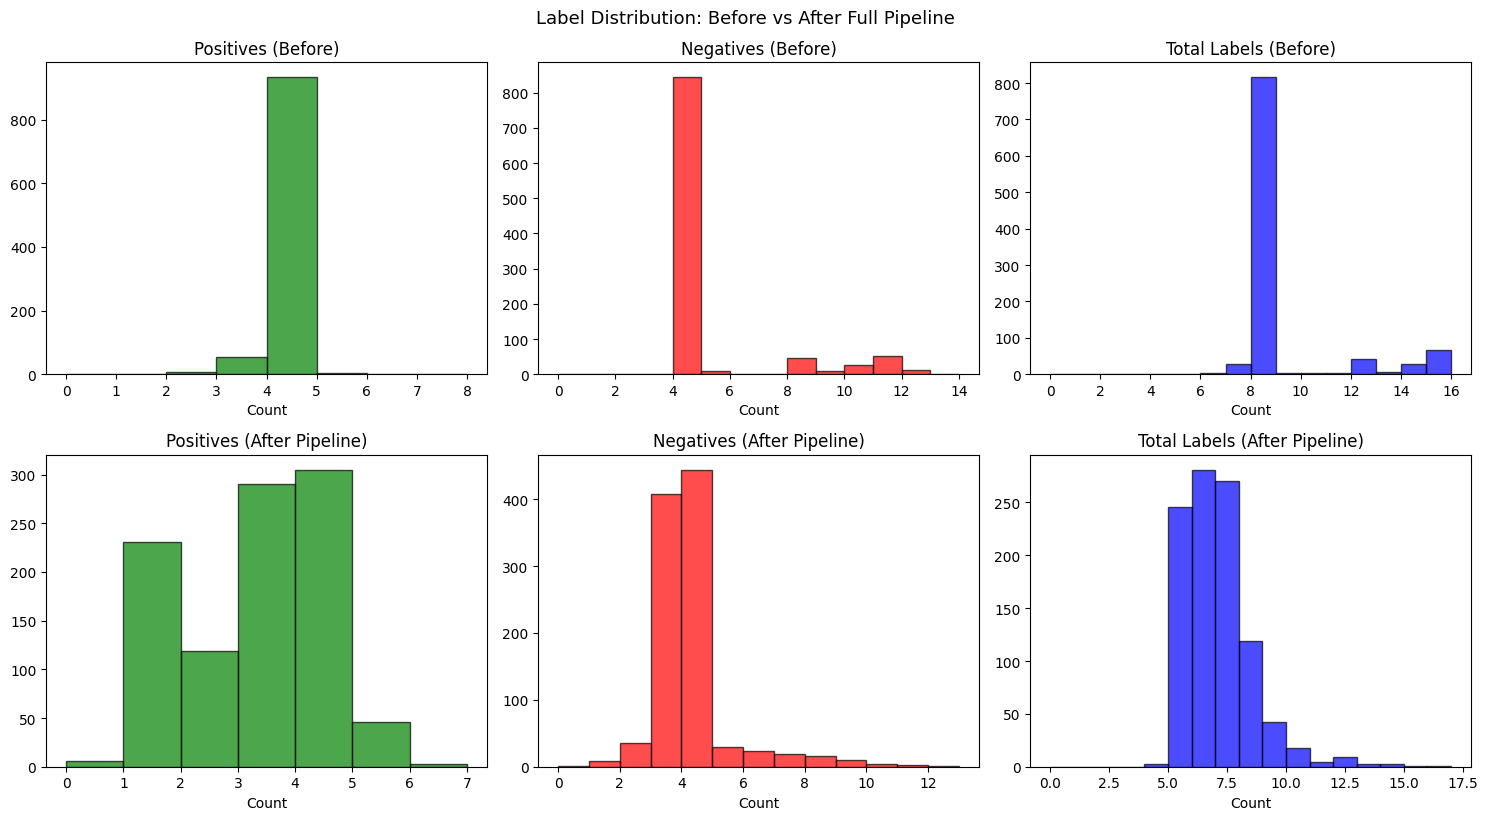

In [11]:
# Load full pipeline from config
pipeline = load_label_augmentation_pipeline("../gliznet/config/augmentation_config.yaml")
print(f"Pipeline: {pipeline}\n")

N_stats = min(1000, len(ds))
pos_before, neg_before, total_before = [], [], []
pos_after, neg_after, total_after = [], [], []

for i in range(N_stats):
    sample = ds[i]
    ltext, lint = sample["ltext"], sample["lint"]

    p = sum(lint)
    n = len(lint) - p
    pos_before.append(p)
    neg_before.append(n)
    total_before.append(len(lint))

    ltext_aug, lint_aug = pipeline(ltext.copy(), lint.copy())
    p2 = sum(lint_aug)
    n2 = len(lint_aug) - p2
    pos_after.append(p2)
    neg_after.append(n2)
    total_after.append(len(lint_aug))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(pos_before, bins=range(0, max(pos_before) + 2), alpha=0.7, color="green", edgecolor="black")
axes[0, 0].set_title("Positives (Before)")
axes[0, 1].hist(neg_before, bins=range(0, max(neg_before) + 2), alpha=0.7, color="red", edgecolor="black")
axes[0, 1].set_title("Negatives (Before)")
axes[0, 2].hist(total_before, bins=range(0, max(total_before) + 2), alpha=0.7, color="blue", edgecolor="black")
axes[0, 2].set_title("Total Labels (Before)")

axes[1, 0].hist(pos_after, bins=range(0, max(pos_after) + 2), alpha=0.7, color="green", edgecolor="black")
axes[1, 0].set_title("Positives (After Pipeline)")
axes[1, 1].hist(neg_after, bins=range(0, max(neg_after) + 2), alpha=0.7, color="red", edgecolor="black")
axes[1, 1].set_title("Negatives (After Pipeline)")
axes[1, 2].hist(total_after, bins=range(0, max(total_after) + 2), alpha=0.7, color="blue", edgecolor="black")
axes[1, 2].set_title("Total Labels (After Pipeline)")

for ax in axes.flat:
    ax.set_xlabel("Count")

plt.tight_layout()
plt.suptitle("Label Distribution: Before vs After Full Pipeline", y=1.02, fontsize=13)
plt.show()

## 6. Pipeline Summary Statistics

In [8]:
print(f"Summary over {N_stats} samples\n" + "=" * 55)
print(f"\n{'Metric':<25} {'Before':>10} {'After':>10}")
print("-" * 55)
print(f"{'Mean positives':<25} {np.mean(pos_before):>10.2f} {np.mean(pos_after):>10.2f}")
print(f"{'Mean negatives':<25} {np.mean(neg_before):>10.2f} {np.mean(neg_after):>10.2f}")
print(f"{'Mean total labels':<25} {np.mean(total_before):>10.2f} {np.mean(total_after):>10.2f}")
print(f"{'Median positives':<25} {np.median(pos_before):>10.1f} {np.median(pos_after):>10.1f}")
print(f"{'Median negatives':<25} {np.median(neg_before):>10.1f} {np.median(neg_after):>10.1f}")
print(f"{'Max total labels':<25} {max(total_before):>10} {max(total_after):>10}")
print(f"{'All-positive samples':<25} {sum(1 for n in neg_before if n == 0):>10} {sum(1 for n in neg_after if n == 0):>10}")
print(f"{'All-negative samples':<25} {sum(1 for p in pos_before if p == 0):>10} {sum(1 for p in pos_after if p == 0):>10}")
print(f"{'Single-positive (needle)':<25} {sum(1 for p in pos_before if p == 1):>10} {sum(1 for p in pos_after if p == 1):>10}")

ratios_before = [p / max(n, 1) for p, n in zip(pos_before, neg_before)]
ratios_after = [p / max(n, 1) for p, n in zip(pos_after, neg_after)]
print(f"\n{'Mean pos/neg ratio':<25} {np.mean(ratios_before):>10.2f} {np.mean(ratios_after):>10.2f}")
print(f"{'Std pos/neg ratio':<25} {np.std(ratios_before):>10.2f} {np.std(ratios_after):>10.2f}")

Summary over 1000 samples

Metric                        Before      After
-------------------------------------------------------
Mean positives                  3.94       2.63
Mean negatives                  4.87       3.78
Mean total labels               8.81       6.41
Median positives                 4.0        3.0
Median negatives                 4.0        4.0
Max total labels                  15         15
All-positive samples               0          0
All-negative samples               0          9
Single-positive (needle)           0        251

Mean pos/neg ratio              0.90       0.82
Std pos/neg ratio               0.22       0.58


---
# Text Augmentation

The text augmentation pipeline introduces subtle noise to simulate real-world typos and informal writing. Each augmenter fires independently with low probability to avoid destroying the text.

| Name | Type | Description |
|------|------|-------------|
| SuffixTruncation | custom | "running" → "runnin" |
| RandomCaseChange | custom | Lowercase capitals |
| KeyboardTypo | nlpaug | QWERTY adjacent key errors |
| OcrTypo | nlpaug | OCR-like substitutions |
| SpellingError | nlpaug | Common misspellings |
| RandomChar(swap) | nlpaug | Adjacent character swap |
| RandomChar(delete) | nlpaug | Delete a character |
| RandomWord(delete) | nlpaug | Delete random words |

## 7. Individual Text Augmenters

Show each augmenter in isolation on a sample text.

In [9]:
sample_text = ds[0]["text"]
print(f"Original:\n  {sample_text}\n")

# Each entry: (registry_name, params for demo visibility)
augmenters = [
    ("SuffixTruncation", {"word_prob": 0.3}),
    ("RandomCaseChange", {"word_prob": 0.3}),
    ("KeyboardTypo", {"aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("OcrTypo", {"aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("SpellingError", {"aug_p": 0.3, "aug_min": 1}),
    ("RandomChar", {"action": "swap", "aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("RandomChar", {"action": "delete", "aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("RandomWord", {"action": "delete", "aug_p": 0.3, "aug_min": 1}),
]

for name, params in augmenters:
    aug = AUGMENTATION_REGISTRY[name](**params)
    result = aug(sample_text)
    label = f"{name}({params.get('action', '')})" if "action" in params else name
    print(f"{label}:")
    print(f"  {result}\n")

Original:
  A highly significant acquisition, this item possesses an aura of authenticated antiquity, possibly connected to the famous HMS York. The sheer complexity of its historical journey, from active service to eventual decommissioning, is palpable. Experts suggest that its material composition aligns with contemporary shipbuilding practices of the era. The estimated valuation reflects not only its physical state but also the prestige associated with its documented naval lineage. Prospective purchasers are advised to review the accompanying scholarly notes meticulously.

SuffixTruncation:
  A highly significant acquisiton, this item possesses an aura of authenticated antiquity, possibly connected to the famous HMS York. The sheer complexity of its historical journey, from active service to eventual decommissioning, is palpable. Experts suggest that its material composition aligns with contemporary shipbuilding practices of the era. The estimated valuaton reflects not only its phys

## 8. Full Text Augmentation Pipeline

Load the pipeline from config and apply it to dataset samples. Each augmenter fires independently with its configured probability — most of the time only 1-2 augmenters trigger per sample.

In [10]:
text_pipeline = load_augmentation_pipeline("../gliznet/config/augmentation_config.yaml")
print(f"Pipeline: {text_pipeline}\n")

# Show 10 samples: original vs augmented
print("Text Augmentation — Before vs After\n" + "=" * 80)
for i in range(10):
    original = ds[i]["text"]
    augmented = text_pipeline(original)
    changed = original != augmented
    print(f"\nSample {i} {'[CHANGED]' if changed else '[UNCHANGED]'}:")
    print(f"  Original:  {original[:100]}{'...' if len(original) > 100 else ''}")
    print(f"  Augmented: {augmented[:100]}{'...' if len(augmented) > 100 else ''}")

Pipeline: AugmentationPipeline([(0.1, SuffixTruncation()), (0.15, KeyboardTypo()), (0.1, OcrTypo()), (0.1, SpellingError()), (0.1, RandomChar()), (0.15, RandomChar()), (0.1, RandomWord()), (0.15, RandomCaseChange())])

Text Augmentation — Before vs After

Sample 0 [UNCHANGED]:
  Original:  A highly significant acquisition, this item possesses an aura of authenticated antiquity, possibly c...
  Augmented: A highly significant acquisition, this item possesses an aura of authenticated antiquity, possibly c...

Sample 1 [UNCHANGED]:
  Original:  One critical factor driving the creation of this new structure was the poor condition of the bridge ...
  Augmented: One critical factor driving the creation of this new structure was the poor condition of the bridge ...

Sample 2 [CHANGED]:
  Original:  The historical record shows a steady, predictable climb in the recognition of sprint champions over ...
  Augmented: The historical record shows a steady, predictale climb in the recognition of spr

## 9. Text Augmentation Statistics

Measure how often text is modified and by how much (edit distance) across a batch of samples.

Texts modified: 117/200 (58.5%)
Avg similarity (SequenceMatcher): 0.939
Min similarity: 0.126


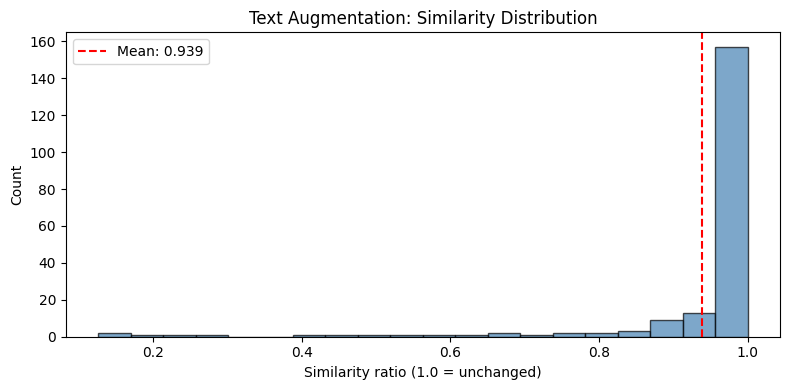

In [11]:
from difflib import SequenceMatcher

N_text = 200
change_count = 0
ratios = []  # similarity ratios

for i in range(N_text):
    original = ds[i]["text"]
    augmented = text_pipeline(original)
    if original != augmented:
        change_count += 1
    ratio = SequenceMatcher(None, original, augmented).ratio()
    ratios.append(ratio)

print(f"Texts modified: {change_count}/{N_text} ({100*change_count/N_text:.1f}%)")
print(f"Avg similarity (SequenceMatcher): {np.mean(ratios):.3f}")
print(f"Min similarity: {np.min(ratios):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratios, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(np.mean(ratios), color="red", linestyle="--", label=f"Mean: {np.mean(ratios):.3f}")
ax.set_xlabel("Similarity ratio (1.0 = unchanged)")
ax.set_ylabel("Count")
ax.set_title("Text Augmentation: Similarity Distribution")
ax.legend()
plt.tight_layout()
plt.show()